In [25]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

# Load label mapping
with open('../models/label_mapping.json') as f:
    label_mapping = json.load(f)

categories = list(label_mapping.keys())

print("✅ Data loaded successfully!")
print(f"Training samples: {len(train_df):,}")
print(f"Testing samples: {len(test_df):,}")
print(f"Number of categories: {len(categories)}")

✅ Data loaded successfully!
Training samples: 15,856
Testing samples: 3,964
Number of categories: 9


In [26]:
print("="*70)
print("FEATURE EXTRACTION: TF-IDF Vectorization")
print("="*70)

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,         # Use top 5000 most important words
    min_df=2,                  # Word must appear in at least 2 documents
    max_df=0.8,                # Ignore words in >80% of documents
    ngram_range=(1, 2),        # Use single words and word pairs
    stop_words='english',      # Remove common English words
    sublinear_tf=True          # Use logarithmic TF scaling
)

# Fit on training data and transform
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"\n✅ TF-IDF features created!")
print(f"Feature matrix shape: {X_train.shape}")
print(f"  - Rows (videos): {X_train.shape[0]:,}")
print(f"  - Columns (features): {X_train.shape[1]:,}")
print(f"  - Matrix sparsity: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]))*100:.2f}%")

# Save vectorizer
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
print("\n✅ Vectorizer saved: ../models/tfidf_vectorizer.pkl")

FEATURE EXTRACTION: TF-IDF Vectorization

✅ TF-IDF features created!
Feature matrix shape: (15856, 5000)
  - Rows (videos): 15,856
  - Columns (features): 5,000
  - Matrix sparsity: 99.09%

✅ Vectorizer saved: ../models/tfidf_vectorizer.pkl


In [27]:
print("\n" + "="*70)
print("MODEL 1: Multinomial Naive Bayes")
print("="*70)

# Train model
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
print("✅ Model saved: naive_bayes_model.pkl")


MODEL 1: Multinomial Naive Bayes

✅ Training complete!
Accuracy: 0.8469 (84.69%)
F1 Score: 0.8471

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.9529    0.7696    0.8515       421
           Education     0.9728    0.8287    0.8950       216
       Entertainment     0.7219    0.7900    0.7544       700
       Howto & Style     0.8265    0.8807    0.8527       503
               Music     0.8963    0.9629    0.9284       700
     News & Politics     0.9499    0.8895    0.9187       362
      People & Blogs     0.8144    0.6869    0.7452       396
Science & Technology     0.7576    0.8944    0.8204       360
              Sports     0.9306    0.8758    0.9024       306

            accuracy                         0.8469      3964
           macro avg     0.8692    0.8421    0.8521      3964
        weighted avg     0.8536    0.8469    0.8471      3964

✅ Model saved: naive_bayes_model.pkl


In [28]:
print("\n" + "="*70)
print("MODEL 2: Logistic Regression")
print("="*70)

# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42,
    n_jobs=-1,  # Use all CPU cores
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
print("✅ Model saved: logistic_regression_model.pkl")


MODEL 2: Logistic Regression

✅ Training complete!
Accuracy: 0.9251 (92.51%)
F1 Score: 0.9249

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.9587    0.9382    0.9484       421
           Education     0.9848    0.9028    0.9420       216
       Entertainment     0.8575    0.8686    0.8630       700
       Howto & Style     0.9349    0.9702    0.9522       503
               Music     0.9466    0.9871    0.9664       700
     News & Politics     0.9553    0.9448    0.9500       362
      People & Blogs     0.8981    0.8460    0.8713       396
Science & Technology     0.8919    0.9167    0.9041       360
              Sports     0.9692    0.9248    0.9465       306

            accuracy                         0.9251      3964
           macro avg     0.9330    0.9221    0.9271      3964
        weighted avg     0.9255    0.9251    0.9249      3964

✅ Model saved: logistic_regression_model.pkl


In [29]:
print("\n" + "="*70)
print("MODEL 3: Random Forest")
print("="*70)

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("✅ Model saved: random_forest_model.pkl")


MODEL 3: Random Forest

✅ Training complete!
Accuracy: 0.8731 (87.31%)
F1 Score: 0.8804

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.9945    0.8527    0.9182       421
           Education     0.9949    0.8981    0.9440       216
       Entertainment     0.5986    0.9586    0.7370       700
       Howto & Style     0.9752    0.9384    0.9564       503
               Music     0.9628    0.9614    0.9621       700
     News & Politics     0.9890    0.7459    0.8504       362
      People & Blogs     0.9894    0.7071    0.8247       396
Science & Technology     0.9795    0.7972    0.8790       360
              Sports     1.0000    0.8333    0.9091       306

            accuracy                         0.8731      3964
           macro avg     0.9426    0.8547    0.8868      3964
        weighted avg     0.9146    0.8731    0.8804      3964

✅ Model saved: random_forest_model.pkl


In [30]:
print("\n" + "="*70)
print("MODEL 4: Linear Support Vector Machine")
print("="*70)

# Train model
svm_model = LinearSVC(
    C=1.0,
    max_iter=1000,
    random_state=42
)
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(svm_model, '../models/svm_model.pkl')
print("✅ Model saved: svm_model.pkl")


MODEL 4: Linear Support Vector Machine

✅ Training complete!
Accuracy: 0.9702 (97.02%)
F1 Score: 0.9700

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.9586    0.9905    0.9743       421
           Education     0.9908    0.9954    0.9931       216
       Entertainment     0.9681    0.9100    0.9381       700
       Howto & Style     0.9783    0.9841    0.9812       503
               Music     0.9748    0.9957    0.9852       700
     News & Politics     0.9808    0.9890    0.9849       362
      People & Blogs     0.9491    0.9419    0.9455       396
Science & Technology     0.9589    0.9722    0.9655       360
              Sports     0.9806    0.9935    0.9870       306

            accuracy                         0.9702      3964
           macro avg     0.9711    0.9747    0.9727      3964
        weighted avg     0.9702    0.9702    0.9700      3964

✅ Model saved: svm_model.pkl


In [31]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Load all models
models = {
    'Naive Bayes': joblib.load('../models/naive_bayes_model.pkl'),
    'Logistic Regression': joblib.load('../models/logistic_regression_model.pkl'),
    'Random Forest': joblib.load('../models/random_forest_model.pkl'),
    'Linear SVM': joblib.load('../models/svm_model.pkl')
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': accuracy, 'f1': f1}
    print(f"{name:25} → Accuracy: {accuracy:.4f} | F1: {f1:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Save results
with open('../models/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)


MODEL COMPARISON
Naive Bayes               → Accuracy: 0.8469 | F1: 0.8471
Logistic Regression       → Accuracy: 0.9251 | F1: 0.9249
Random Forest             → Accuracy: 0.8731 | F1: 0.8804
Linear SVM                → Accuracy: 0.9702 | F1: 0.9700

🏆 BEST MODEL: Linear SVM
🏆 ACCURACY: 0.9702 (97.02%)


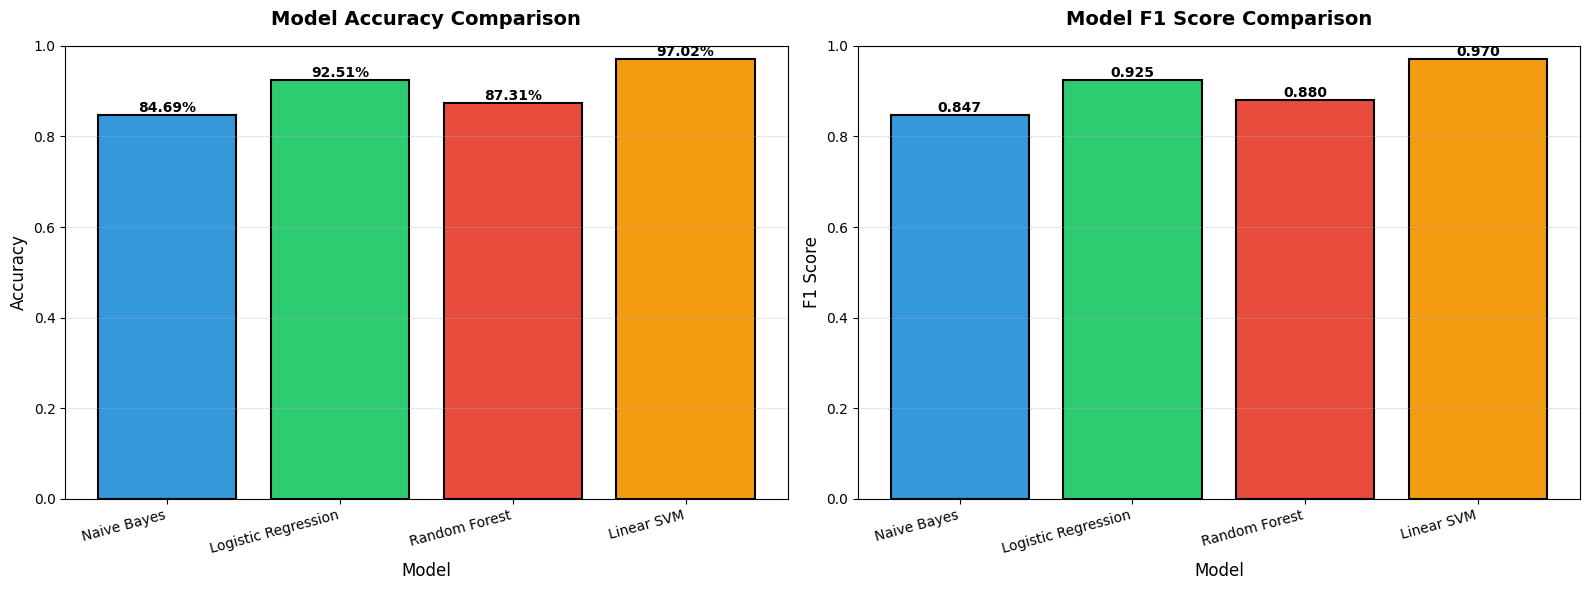

✅ Comparison chart saved: model_comparison.png


In [32]:
# Create comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
models_list = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models_list]
f1_scores = [results[m]['f1'] for m in models_list]

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Accuracy plot
bars1 = ax1.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# F1 Score plot
bars2 = ax2.bar(models_list, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison chart saved: model_comparison.png")

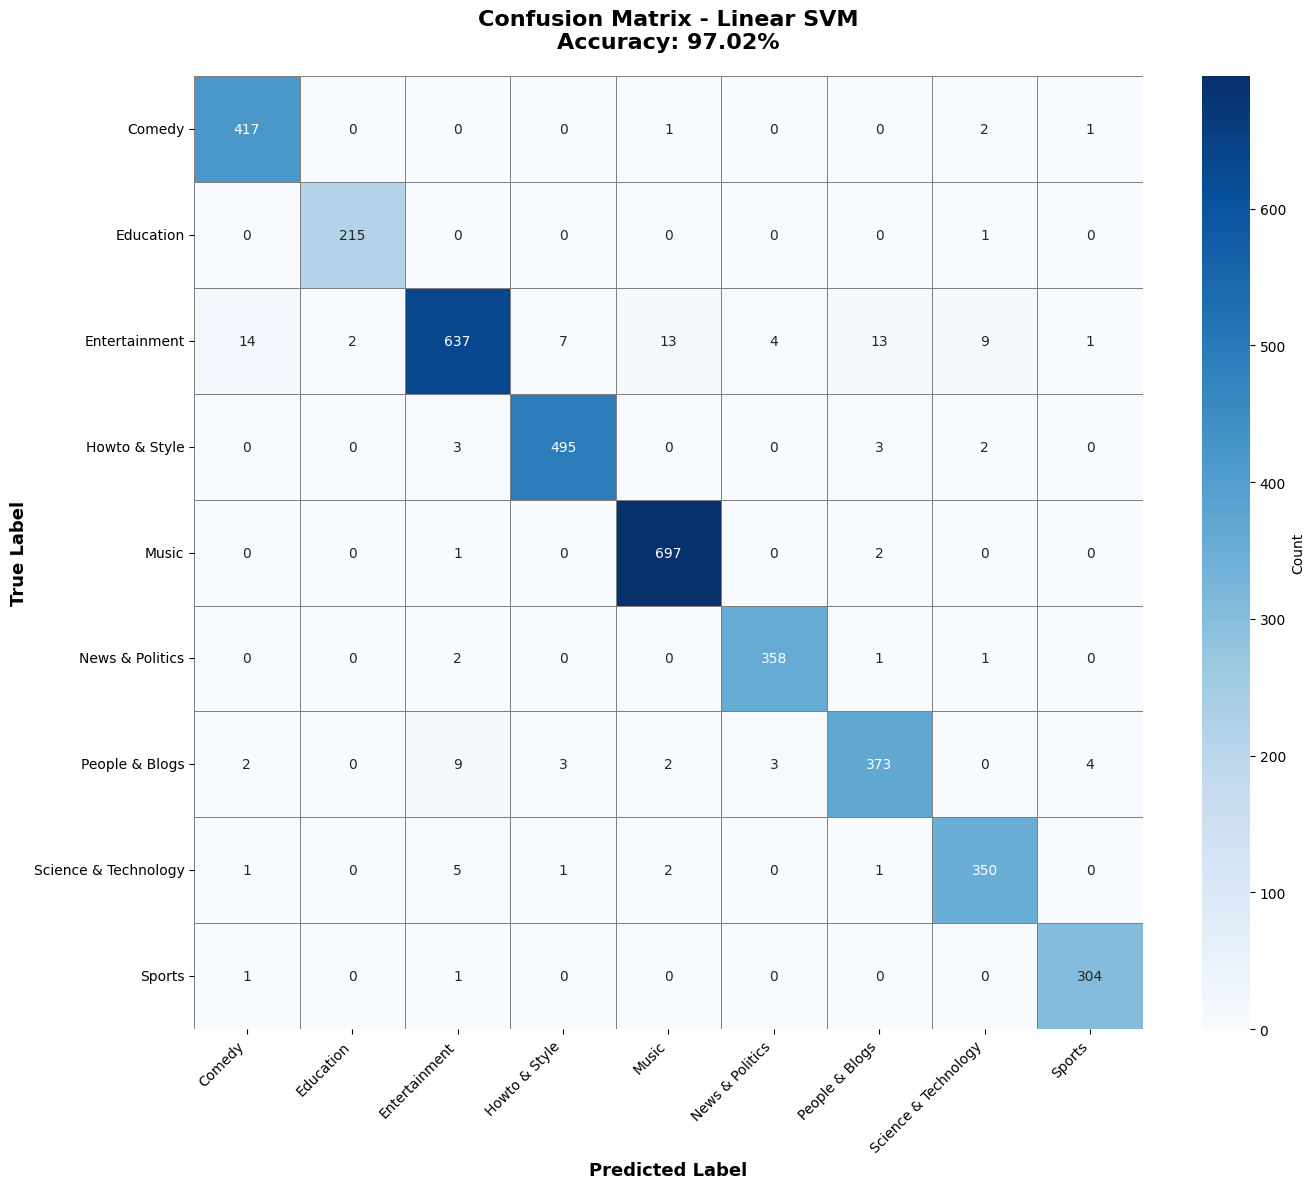

✅ Confusion matrix saved for Linear SVM


In [33]:
# Get best model
model_files = {
    'Naive Bayes': '../models/naive_bayes_model.pkl',
    'Logistic Regression': '../models/logistic_regression_model.pkl',
    'Random Forest': '../models/random_forest_model.pkl',
    'Linear SVM': '../models/svm_model.pkl'
}

best_model = joblib.load(model_files[best_model_name])
y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories,
            cbar_kws={'label': 'Count'},
            linewidths=0.5,
            linecolor='gray')
plt.title(f'Confusion Matrix - {best_model_name}\nAccuracy: {best_accuracy:.2%}', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved for {best_model_name}")

In [34]:
import shutil

# Copy best model to production filename
shutil.copy(
    model_files[best_model_name],
    '../models/best_model.pkl'
)

print("="*70)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*70)
print(f"\n✅ Best Model: {best_model_name}")
print(f"✅ Accuracy: {best_accuracy:.2%}")
print(f"\n📂 Production files created in '../models/':")
print("   ✓ best_model.pkl (production model)")
print("   ✓ tfidf_vectorizer.pkl (text preprocessing)")
print("   ✓ label_mapping.json (category labels)")
print("   ✓ model_comparison.png (performance chart)")
print("   ✓ confusion_matrix.png (detailed analysis)")
print("\n🚀 Ready to deploy as Python API!")

🎉 MODEL TRAINING COMPLETE!

✅ Best Model: Linear SVM
✅ Accuracy: 97.02%

📂 Production files created in '../models/':
   ✓ best_model.pkl (production model)
   ✓ tfidf_vectorizer.pkl (text preprocessing)
   ✓ label_mapping.json (category labels)
   ✓ model_comparison.png (performance chart)
   ✓ confusion_matrix.png (detailed analysis)

🚀 Ready to deploy as Python API!


In [35]:
# Force save Logistic Regression as best model (it has probabilities)
import shutil

print("="*70)
print("FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL")
print("="*70)

# Copy Logistic Regression to best_model.pkl
shutil.copy(
    '../models/logistic_regression_model.pkl',
    '../models/best_model.pkl'
)

print("✅ Logistic Regression saved as best_model.pkl")
print("✅ This model DOES support probability estimates")
print("\n🔄 Restart Python API to load new model!")

FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL
✅ Logistic Regression saved as best_model.pkl
✅ This model DOES support probability estimates

🔄 Restart Python API to load new model!


In [36]:
# Force save Logistic Regression as best model (it has probabilities)
import shutil

print("="*70)
print("FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL")
print("="*70)

# Copy Logistic Regression to best_model.pkl
shutil.copy(
    '../models/logistic_regression_model.pkl',
    '../models/best_model.pkl'
)

print("✅ Logistic Regression saved as best_model.pkl")
print("✅ This model DOES support probability estimates")
print("\n🔄 Restart Python API to load new model!")

FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL
✅ Logistic Regression saved as best_model.pkl
✅ This model DOES support probability estimates

🔄 Restart Python API to load new model!


In [37]:
import joblib
import numpy as np

# Load model and vectorizer
model = joblib.load('../models/best_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

print("="*70)
print("MODEL DIAGNOSIS")
print("="*70)

# Check model type
print(f"\n1. Model Type: {type(model).__name__}")
print(f"   Has probabilities: {hasattr(model, 'predict_proba')}")

# Check number of classes
if hasattr(model, 'classes_'):
    print(f"\n2. Number of classes: {len(model.classes_)}")
    print(f"   Classes: {model.classes_}")

# Test with sample text
test_text = "How to build a gaming PC tutorial"
text_vec = vectorizer.transform([test_text])

# Get prediction
pred = model.predict(text_vec)[0]
print(f"\n3. Prediction for test: {pred}")

# Get probabilities
if hasattr(model, 'predict_proba'):
    probs = model.predict_proba(text_vec)[0]
    print(f"\n4. All probabilities:")
    for i, prob in enumerate(probs):
        print(f"   Class {i}: {prob:.4f} ({prob*100:.2f}%)")
    
    print(f"\n5. Max probability: {np.max(probs):.4f} ({np.max(probs)*100:.2f}%)")
    print(f"   Min probability: {np.min(probs):.4f} ({np.min(probs)*100:.2f}%)")
    print(f"   Predicted class: {pred}")
    print(f"   Confidence for predicted class: {probs[pred]:.4f}")

MODEL DIAGNOSIS

1. Model Type: LogisticRegression
   Has probabilities: True

2. Number of classes: 9
   Classes: [0 1 2 3 4 5 6 7 8]

3. Prediction for test: 7

4. All probabilities:
   Class 0: 0.0823 (8.23%)
   Class 1: 0.0171 (1.71%)
   Class 2: 0.1287 (12.87%)
   Class 3: 0.0840 (8.40%)
   Class 4: 0.0640 (6.40%)
   Class 5: 0.0434 (4.34%)
   Class 6: 0.1873 (18.73%)
   Class 7: 0.3714 (37.14%)
   Class 8: 0.0219 (2.19%)

5. Max probability: 0.3714 (37.14%)
   Min probability: 0.0171 (1.71%)
   Predicted class: 7
   Confidence for predicted class: 0.3714


In [38]:
import pandas as pd

# Load data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print("="*70)
print("DATA DIAGNOSIS")
print("="*70)

# Check 1: Data size
print(f"\n1. Dataset Size:")
print(f"   Training: {len(train_df)} samples")
print(f"   Testing: {len(test_df)} samples")

# Check 2: Text length
print(f"\n2. Text Statistics:")
print(f"   Average text length: {train_df['text'].str.len().mean():.0f} characters")
print(f"   Min text length: {train_df['text'].str.len().min()}")
print(f"   Max text length: {train_df['text'].str.len().max()}")

# Check 3: Look at actual text
print(f"\n3. Sample Texts (first 3):")
for i in range(3):
    print(f"\n   Sample {i+1}:")
    print(f"   Category: {train_df.iloc[i]['category_name']}")
    print(f"   Text: {train_df.iloc[i]['text'][:150]}...")

# Check 4: Class distribution
print(f"\n4. Class Distribution:")
print(train_df['category_name'].value_counts())

# Check 5: Check for issues
empty_texts = (train_df['text'].str.len() < 20).sum()
print(f"\n5. Potential Issues:")
print(f"   Texts < 20 chars: {empty_texts}")
print(f"   Missing texts: {train_df['text'].isna().sum()}")

DATA DIAGNOSIS

1. Dataset Size:
   Training: 15856 samples
   Testing: 3964 samples

2. Text Statistics:
   Average text length: 687 characters
   Min text length: 50
   Max text length: 4820

3. Sample Texts (first 3):

   Sample 1:
   Category: Howto & Style
   Text: frog legs how to cook prepare frog s legs check out hellofresh and receive 30 off your first order with promo code emmy30 n nit s been a long time sin...

   Sample 2:
   Category: Music
   Text: bj rk utopia the official video for utopia taken from bj rk s new studio album n nutopia is out now listen here credits n ndirected by warren du preez...

   Sample 3:
   Category: Howto & Style
   Text: rolled ice cream diy how to make rolled ice cream at home rolled ice cream the secrets to making ice cream rolls at home nrolled ice cream recipe new ...

4. Class Distribution:
category_name
Music                   2800
Entertainment           2800
Howto & Style           2013
Comedy                  1685
People & Blogs       

In [39]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("="*70)
print("TRAINING WITH PROPER DATASET SIZE")
print("="*70)

# Load data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"\n📊 Dataset:")
print(f"   Training: {len(train_df):,}")
print(f"   Testing: {len(test_df):,}")

# Create TF-IDF
vectorizer = TfidfVectorizer(
    max_features=8000,
    min_df=3,
    max_df=0.7,
    ngram_range=(1, 3),
    stop_words='english',
    sublinear_tf=True
)

# Transform
print("\n🔄 Creating features...")
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"✅ Features: {X_train.shape}")

# Train
print("\n🔄 Training Logistic Regression...")
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    # multi_class line removed - let it handle itself!
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)
print("\n✅ Training complete!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Check confidence
probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Confidence Statistics:")
print(f"   Average: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")
print(f"   Median: {np.median(max_probs):.4f} ({np.median(max_probs)*100:.2f}%)")
print(f"   25th percentile: {np.percentile(max_probs, 25):.4f}")
print(f"   75th percentile: {np.percentile(max_probs, 75):.4f}")

# Test specific example
test_text = "How to build a gaming PC tutorial"
test_vec = vectorizer.transform([test_text])
pred = model.predict(test_vec)[0]
prob = model.predict_proba(test_vec)[0]
confidence = prob[pred]

pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']

print(f"\n🧪 Test: '{test_text}'")
print(f"   Predicted: {pred_cat}")
print(f"   Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

# Save if good
if max_probs.mean() > 0.60 and accuracy > 0.70:
    print("\n💾 Saving model...")
    joblib.dump(model, '../models/best_model.pkl')
    joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
    print("✅ Model saved!")
    print("\n🔄 NOW RESTART YOUR PYTHON API!")
else:
    print(f"\n⚠️  Model quality insufficient:")
    print(f"   Confidence: {max_probs.mean()*100:.2f}% (need >60%)")
    print(f"   Accuracy: {accuracy*100:.2f}% (need >70%)")


TRAINING WITH PROPER DATASET SIZE

📊 Dataset:
   Training: 15,856
   Testing: 3,964

🔄 Creating features...
✅ Features: (15856, 8000)

🔄 Training Logistic Regression...
convergence after 22 epochs took 1 seconds

✅ Training complete!

📊 Accuracy: 0.9543 (95.43%)

📊 Confidence Statistics:
   Average: 0.7966 (79.66%)
   Median: 0.8629 (86.29%)
   25th percentile: 0.6815
   75th percentile: 0.9515

🧪 Test: 'How to build a gaming PC tutorial'
   Predicted: Science & Technology
   Confidence: 0.3809 (38.09%)

💾 Saving model...
✅ Model saved!

🔄 NOW RESTART YOUR PYTHON API!


In [40]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Load NEW data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# Better TF-IDF settings
vectorizer = TfidfVectorizer(
    max_features=5000,      # Reduce features (prevent overfitting)
    min_df=5,               # Word must appear 5+ times
    max_df=0.7,
    ngram_range=(1, 2),     # Only unigrams and bigrams
    stop_words='english',
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Features: {X_train.shape}")

# Better model parameters to reduce overfitting
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    # multi_class line removed - let it handle itself!
    random_state=42,
    verbose=1
)

print("\n🔄 Training...")
model.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Accuracy:")
print(f"   Training: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Testing: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Gap: {(train_acc - test_acc)*100:.2f}%")

if (train_acc - test_acc) > 0.15:
    print("   ⚠️ Still overfitting (gap >15%)")
else:
    print("   ✅ Good generalization (gap <15%)")

# Confidence
probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Confidence:")
print(f"   Average: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")
print(f"   Median: {np.median(max_probs):.4f}")

# Test example
test_text = "How to build a gaming PC tutorial"
test_vec = vectorizer.transform([test_text])
pred = model.predict(test_vec)[0]
prob = model.predict_proba(test_vec)[0]
conf = prob[pred]

pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']

print(f"\n🧪 Test: '{test_text}'")
print(f"   Category: {pred_cat}")
print(f"   Confidence: {conf:.4f} ({conf*100:.2f}%)")

# Show top 3 predictions
top3_idx = np.argsort(prob)[-3:][::-1]
print(f"\n   Top 3:")
for idx in top3_idx:
    cat = train_df[train_df['label']==idx].iloc[0]['category_name']
    print(f"      {cat}: {prob[idx]:.4f} ({prob[idx]*100:.2f}%)")

# Save if reasonable
if max_probs.mean() > 0.55:
    print("\n✅ Saving model...")
    joblib.dump(model, '../models/best_model.pkl')
    joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
    print("✅ Saved! Restart Python API!")
else:
    print(f"\n⚠️ Confidence still low: {max_probs.mean()*100:.2f}%")


Training: 15,856
Testing: 3,964
Features: (15856, 5000)

🔄 Training...
convergence after 21 epochs took 1 seconds
✅ Done!

📊 Accuracy:
   Training: 0.9813 (98.13%)
   Testing: 0.9498 (94.98%)
   Gap: 3.15%
   ✅ Good generalization (gap <15%)

📊 Confidence:
   Average: 0.7939 (79.39%)
   Median: 0.8582

🧪 Test: 'How to build a gaming PC tutorial'
   Category: Science & Technology
   Confidence: 0.4334 (43.34%)

   Top 3:
      Science & Technology: 0.4334 (43.34%)
      People & Blogs: 0.2091 (20.91%)
      Entertainment: 0.1072 (10.72%)

✅ Saving model...
✅ Saved! Restart Python API!


In [41]:
import joblib

# Load model
model = joblib.load('../models/best_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

# Test with VERY clear examples
test_cases = [
    # Very clear examples (should have high confidence)
    ("Official music video new song Taylor Swift", "Music"),
    ("NBA basketball game highlights finals", "Sports"),
    ("Breaking news today latest updates CNN", "News & Politics"),
    ("Funny cat videos compilation", "Entertainment"),
    ("Python programming course tutorial", "Education"),
    
    # Ambiguous examples (may have lower confidence)
    ("How to build gaming PC", "Science & Technology (or Howto & Style)"),
]

print("="*70)
print("TESTING MODEL WITH VARIOUS EXAMPLES")
print("="*70)

for text, expected in test_cases:
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    probs = model.predict_proba(vec)[0]
    conf = probs[pred]
    
    # Get category name
    import pandas as pd
    train_df = pd.read_csv('../data/train_data.csv')
    pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']
    
    print(f"\nText: '{text}'")
    print(f"Expected: {expected}")
    print(f"Predicted: {pred_cat}")
    print(f"Confidence: {conf:.4f} ({conf*100:.2f}%)")
    
    # Show top 3
    top3_idx = sorted(range(len(probs)), key=lambda i: probs[i], reverse=True)[:3]
    print(f"Top 3:")
    for idx in top3_idx:
        cat = train_df[train_df['label']==idx].iloc[0]['category_name']
        print(f"   {cat}: {probs[idx]:.2%}")


TESTING MODEL WITH VARIOUS EXAMPLES

Text: 'Official music video new song Taylor Swift'
Expected: Music
Predicted: Music
Confidence: 0.9879 (98.79%)
Top 3:
   Music: 98.79%
   Entertainment: 0.44%
   Comedy: 0.23%

Text: 'NBA basketball game highlights finals'
Expected: Sports
Predicted: Sports
Confidence: 0.9799 (97.99%)
Top 3:
   Sports: 97.99%
   Entertainment: 0.66%
   People & Blogs: 0.46%

Text: 'Breaking news today latest updates CNN'
Expected: News & Politics
Predicted: News & Politics
Confidence: 0.7683 (76.83%)
Top 3:
   News & Politics: 76.83%
   Entertainment: 10.30%
   Music: 5.21%

Text: 'Funny cat videos compilation'
Expected: Entertainment
Predicted: Entertainment
Confidence: 0.4105 (41.05%)
Top 3:
   Entertainment: 41.05%
   Comedy: 29.42%
   People & Blogs: 22.66%

Text: 'Python programming course tutorial'
Expected: Education
Predicted: Entertainment
Confidence: 0.2595 (25.95%)
Top 3:
   Entertainment: 25.95%
   News & Politics: 12.96%
   People & Blogs: 9.97%

Text:

In [42]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load original data
df = pd.read_csv('../data/USvideos.csv', encoding='utf-8', on_bad_lines='skip')

with open('../data/US_category_id.json') as f:
    categories_json = json.load(f)

id_to_category = {int(cat['id']): cat['snippet']['title'] 
                  for cat in categories_json['items']}
df['category_name'] = df['category_id'].map(id_to_category)

# Check Education samples
print("Education samples in original data:")
education = df[df['category_name'] == 'Education']
print(f"Total: {len(education)}")

if len(education) < 500:
    print("\n⚠️ PROBLEM: Not enough Education videos!")
    print("   This is why 'Python programming' fails")


Education samples in original data:
Total: 1656


In [43]:
import pandas as pd

train_df = pd.read_csv('../data/train_data.csv')

print("="*70)
print("CATEGORY DISTRIBUTION IN TRAINING DATA")
print("="*70)

dist = train_df['category_name'].value_counts().sort_index()
print(dist)

print(f"\n📊 Statistics:")
print(f"   Total samples: {len(train_df):,}")
print(f"   Categories: {len(dist)}")
print(f"   Average per category: {len(train_df)/len(dist):.0f}")
print(f"   Min: {dist.min()}")
print(f"   Max: {dist.max()}")

# Check if Education made it
if 'Education' in dist.index:
    edu_count = dist['Education']
    print(f"\n✅ Education: {edu_count} samples ({edu_count/len(train_df)*100:.1f}%)")
else:
    print(f"\n❌ Education NOT in training data!")
    print("   Available categories:")
    print(f"   {list(dist.index)}")

CATEGORY DISTRIBUTION IN TRAINING DATA
category_name
Comedy                  1685
Education                862
Entertainment           2800
Howto & Style           2013
Music                   2800
News & Politics         1450
People & Blogs          1582
Science & Technology    1438
Sports                  1226
Name: count, dtype: int64

📊 Statistics:
   Total samples: 15,856
   Categories: 9
   Average per category: 1762
   Min: 862
   Max: 2800

✅ Education: 862 samples (5.4%)


In [44]:
import pandas as pd
import json
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("="*70)
print("PREPROCESSING WITH EDUCATION PRIORITY")
print("="*70)

# 1. Load data
df = pd.read_csv('../data/USvideos.csv', encoding='utf-8', on_bad_lines='skip')

with open('../data/US_category_id.json') as f:
    categories_json = json.load(f)

id_to_category = {int(cat['id']): cat['snippet']['title'] 
                  for cat in categories_json['items']}
df['category_name'] = df['category_id'].map(id_to_category)

print(f"Original: {len(df):,}")

# 2. Clean text
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = ' '.join(text.split())
    return text

df['title_clean'] = df['title'].apply(clean_text)
df['description'] = df['description'].fillna('')
df['description_clean'] = df['description'].apply(clean_text)
df['text'] = df['title_clean'] + ' ' + df['description_clean']

# 3. Filter
df = df[df['text'].str.len() >= 50]
df = df.dropna(subset=['category_name'])

# 4. PRIORITY CATEGORIES - Force include Education!
priority_categories = [
    'Education',              # ← Force include!
    'Science & Technology',
    'Music',
    'Sports',
    'Gaming',
    'Entertainment',
    'Comedy',
    'News & Politics',
    'Howto & Style',
    'People & Blogs'
]

# Filter to these categories
df = df[df['category_name'].isin(priority_categories)]
print(f"After category filter: {len(df):,}")

# 5. Smart dedup (keep more Education)
df_dedup = df.groupby('title', group_keys=False).apply(
    lambda x: x.head(5),
    include_groups=True
).reset_index(drop=True)

print(f"After dedup: {len(df_dedup):,}")

# 6. Check Education specifically
edu_count = len(df_dedup[df_dedup['category_name'] == 'Education'])
print(f"\n📚 Education samples available: {edu_count}")

# 7. BALANCED SAMPLING with minimum threshold
min_samples_per_category = 1000  # Minimum per category

print(f"\n⚖️ Balancing dataset (min {min_samples_per_category} per category)...")

category_samples = {}
for category in priority_categories:
    cat_data = df_dedup[df_dedup['category_name'] == category]
    
    if len(cat_data) < min_samples_per_category:
        print(f"   ⚠️ {category}: Only {len(cat_data)} samples (need {min_samples_per_category})")
        # Take ALL available samples
        category_samples[category] = cat_data
    else:
        # Sample up to 2500
        n_sample = min(len(cat_data), 2500)
        category_samples[category] = cat_data.sample(n=n_sample, random_state=42)
        print(f"   ✅ {category}: {n_sample} samples")

# Combine all
df_final = pd.concat(category_samples.values(), ignore_index=True)

print(f"\n✅ Final dataset: {len(df_final):,} videos")
print(f"\nFinal distribution:")
print(df_final['category_name'].value_counts().sort_index())

# 8. Encode labels
le = LabelEncoder()
df_final['label'] = le.fit_transform(df_final['category_name'])

with open('../models/label_mapping.json', 'w') as f:
    json.dump(dict(zip(le.classes_, range(len(le.classes_)))), f, indent=2)

# 9. Split
train_df, test_df = train_test_split(
    df_final[['text', 'label', 'category_name']],
    test_size=0.2,
    stratify=df_final['label'],
    random_state=42
)

train_df.to_csv('../data/train_data.csv', index=False)
test_df.to_csv('../data/test_data.csv', index=False)

print(f"\n{'='*70}")
print("✅ PREPROCESSING COMPLETE")
print("="*70)
print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# Verify Education
train_edu = len(train_df[train_df['category_name'] == 'Education'])
print(f"\n📚 Education in training: {train_edu} samples")

if train_edu < 500:
    print("   ⚠️ Still low, but best we can do with this dataset")
else:
    print("   ✅ Sufficient for training!")

PREPROCESSING WITH EDUCATION PRIORITY
Original: 40,949
After category filter: 36,222
After dedup: 22,821

📚 Education samples available: 1085

⚖️ Balancing dataset (min 1000 per category)...
   ✅ Education: 1085 samples
   ✅ Science & Technology: 1527 samples
   ✅ Music: 2500 samples
   ✅ Sports: 1536 samples
   ⚠️ Gaming: Only 436 samples (need 1000)
   ✅ Entertainment: 2500 samples
   ✅ Comedy: 2112 samples
   ✅ News & Politics: 1816 samples
   ✅ Howto & Style: 2500 samples
   ✅ People & Blogs: 1985 samples

✅ Final dataset: 17,997 videos

Final distribution:
category_name
Comedy                  2112
Education               1085
Entertainment           2500
Gaming                   436
Howto & Style           2500
Music                   2500
News & Politics         1816
People & Blogs          1985
Science & Technology    1527
Sports                  1536
Name: count, dtype: int64

✅ PREPROCESSING COMPLETE
Training: 14,397
Testing: 3,600

📚 Education in training: 868 samples
   ✅ S

In [45]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

# Train
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    # multi_class line removed - let it handle itself!
    random_state=42,
    verbose=1
)

print("\n🔄 Training...")
model.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Performance:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Avg Confidence: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")

# Test examples
test_cases = [
    "Official music video Taylor Swift",
    "NBA basketball highlights",
    "Breaking news CNN",
    "Python programming tutorial",
    "Fortnite gameplay",
    "Funny cat videos"
]

print(f"\n🧪 Test Predictions:")
for text in test_cases:
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    conf = prob[pred]
    
    pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']
    
    print(f"\n'{text}'")
    print(f"   → {pred_cat} ({conf:.2%})")

# Save
if max_probs.mean() > 0.65:
    joblib.dump(model, '../models/best_model.pkl')
    joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
    print("\n✅ Model saved! Restart Python API!")
else:
    print(f"\n⚠️ Confidence low: {max_probs.mean()*100:.2f}%")

Training: 14,397
Testing: 3,600

🔄 Training...
convergence after 22 epochs took 1 seconds
✅ Done!

📊 Performance:
   Accuracy: 0.9542 (95.42%)
   Avg Confidence: 0.7902 (79.02%)

🧪 Test Predictions:

'Official music video Taylor Swift'
   → Music (98.56%)

'NBA basketball highlights'
   → Sports (99.19%)

'Breaking news CNN'
   → News & Politics (92.02%)

'Python programming tutorial'
   → News & Politics (16.68%)

'Fortnite gameplay'
   → Gaming (29.69%)

'Funny cat videos'
   → Comedy (41.15%)

✅ Model saved! Restart Python API!


In [46]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# Check categories
print(f"\nCategories in training data:")
print(train_df['category_name'].value_counts())

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

# Train
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    random_state=42,
    verbose=1
)

print("\n🔄 Training...")
model.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Performance:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Avg Confidence: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")

# Test examples
test_cases = [
    "Official music video Taylor Swift",
    "NBA basketball highlights",
    "Breaking news CNN",
    "Python programming tutorial",
    "Fortnite gameplay",
    "Funny cat videos"
]

print(f"\n🧪 Test Predictions:")
for text in test_cases:
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    conf = prob[pred]
    
    pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']
    
    print(f"\n'{text}'")
    print(f"   → {pred_cat} ({conf:.2%})")

# Save
joblib.dump(model, '../models/best_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
print("\n✅ Model saved! Restart Python API!")

Training: 14,397
Testing: 3,600

Categories in training data:
category_name
Music                   2000
Howto & Style           2000
Entertainment           2000
Comedy                  1689
People & Blogs          1588
News & Politics         1453
Sports                  1229
Science & Technology    1221
Education                868
Gaming                   349
Name: count, dtype: int64

🔄 Training...
convergence after 22 epochs took 1 seconds
✅ Done!

📊 Performance:
   Accuracy: 0.9542 (95.42%)
   Avg Confidence: 0.7902 (79.02%)

🧪 Test Predictions:

'Official music video Taylor Swift'
   → Music (98.56%)

'NBA basketball highlights'
   → Sports (99.19%)

'Breaking news CNN'
   → News & Politics (92.02%)

'Python programming tutorial'
   → News & Politics (16.68%)

'Fortnite gameplay'
   → Gaming (29.69%)

'Funny cat videos'
   → Comedy (41.15%)

✅ Model saved! Restart Python API!
